# 02 · Exploratory Data Analysis

**Goal:** understand *what drives delivery-route delays* before we build any model.
EDA is where a business analyst adds the most value — we're not just plotting, we're
building the story that the model will later confirm and quantify.

We'll answer:
1. How imbalanced is the target? (what share of routes are delayed)
2. Which operational factors move the delay rate the most?
3. Do delayed vs on-time routes actually *look* different?
4. Which features correlate with delay — and which columns are **leakage** we must exclude?

Every chart here is a candidate slide for the final business dashboard.


## 1 · Setup and load the data

In [35]:
# Make the src/ folder importable no matter where Jupyter launched from
import sys, os
for p in ['../src', 'src', os.path.join(os.getcwd(), 'src')]:
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import data_generation as dg

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 60)

# Regenerate the exact same dataset in memory (seed is fixed, so this equals your CSV).
# Alternative: df = pd.read_csv('../data/raw/delivery_routes.csv', parse_dates=['route_date'])
df = dg.generate()
print("shape:", df.shape)
df.head()

shape: (12000, 31)


,route_id,route_date,dc,region,route_type,vehicle_type,day_of_week,is_monday,is_month_end,holiday_week_flag,planned_stops,planned_miles,planned_cases,planned_weight_lbs,planned_duration_min,warehouse_load_delay_min,picker_shortage_flag,load_complexity_score,start_delay_min,driver_tenure_days,driver_route_familiarity,driver_avg_delay_rate,delivery_window_pressure,retail_stop_pct,restaurant_stop_pct,weather_severity,traffic_index,actual_duration_min,actual_end_offset_min,route_delay_min,is_delayed
0,RT-007124,2025-01-01,DC_PHOENIX,Southwest,rural,van,Wed,0,0,0,8,224,362,8172,407,20,0,7.2,20,910,1,0.210,high,0.75,0.17,0,35,331,-76,-76,0
1,RT-001705,2025-01-01,DC_DENVER,Mountain,urban,box_truck,Wed,0,0,1,30,33,1167,26842,476,32,1,5.1,13,691,1,0.102,low,0.66,0.28,1,55,431,-45,-45,0
2,RT-001679,2025-01-01,DC_DENVER,Mountain,rural,tractor_trailer,Wed,0,0,0,12,177,494,11525,451,19,0,7.8,0,501,0,0.301,medium,0.29,0.54,1,53,428,-23,-23,0
3,RT-001812,2025-01-01,DC_PHOENIX,Southwest,suburban,van,Wed,0,0,0,30,145,929,19200,574,61,1,2.2,25,138,1,0.130,low,0.69,0.05,2,64,515,-59,-59,0
4,RT-000721,2025-01-01,DC_ATLANTA,Southeast,urban,van,Wed,0,0,0,30,20,1066,26915,463,19,0,5.2,4,1874,1,0.122,medium,0.81,0.00,2,64,417,-46,-46,0


In [36]:
# Quick structural overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   route_id                  12000 non-null  str           
 1   route_date                12000 non-null  datetime64[us]
 2   dc                        12000 non-null  str           
 3   region                    12000 non-null  str           
 4   route_type                12000 non-null  str           
 5   vehicle_type              12000 non-null  str           
 6   day_of_week               12000 non-null  str           
 7   is_monday                 12000 non-null  int64         
 8   is_month_end              12000 non-null  int64         
 9   holiday_week_flag         12000 non-null  int64         
 10  planned_stops             12000 non-null  int64         
 11  planned_miles             12000 non-null  int64         
 12  planned_cases             120

## 2 · How imbalanced is the target?

At ~25% delayed, a lazy model that predicts *"never delayed"* would be ~75% accurate
while catching zero delays. That's exactly why we'll later judge the model on
**recall / precision**, not accuracy.


is_delayed
on-time    0.746917
delayed    0.253083
Name: proportion, dtype: float64


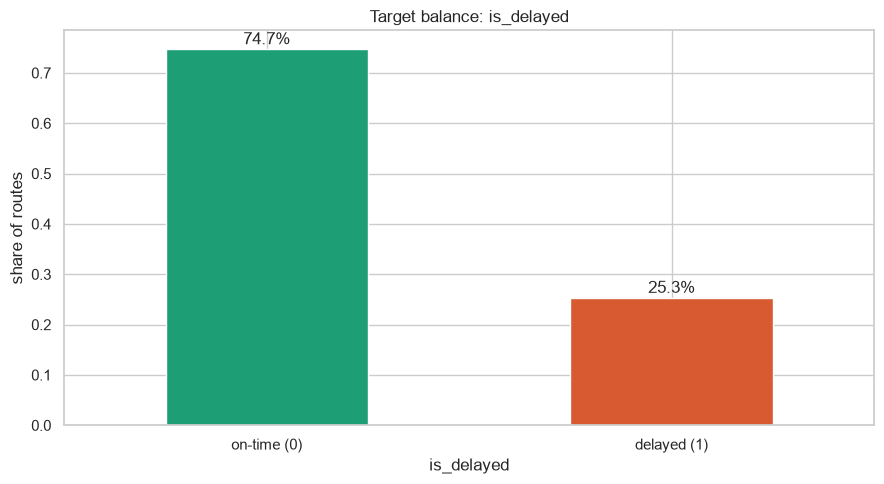

In [37]:
balance = df['is_delayed'].value_counts(normalize=True).sort_index()
print(balance.rename({0: 'on-time', 1: 'delayed'}))

ax = balance.plot(kind='bar', color=['#1D9E75', '#D85A30'])
ax.set_xticklabels(['on-time (0)', 'delayed (1)'], rotation=0)
ax.set_ylabel('share of routes')
ax.set_title('Target balance: is_delayed')
for i, v in enumerate(balance.values):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center')
plt.tight_layout(); plt.show()

## 3 · What drives the delay rate?

Reusable helper: for any column, compute the **delay rate within each bucket** and plot it.
Delay rate (not raw counts) is the operationally meaningful number — it's the probability
a route in that bucket ends late.


In [38]:
def delay_rate_by(col, bins=None, labels=None, order=None, title=None):
    d = df.copy()
    d['_grp'] = pd.cut(d[col], bins=bins, labels=labels) if bins is not None else d[col]
    rate = d.groupby('_grp', observed=True)['is_delayed'].mean()
    if order is not None:
        rate = rate.reindex(order)
    ax = rate.plot(kind='bar', color=sns.color_palette('flare', len(rate)))
    ax.set_ylabel('delay rate'); ax.set_xlabel(col)
    ax.set_title(title or f'Delay rate by {col}')
    ax.set_ylim(0, min(1, rate.max() * 1.25))
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontsize=9)
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
    return rate

### 3a · Warehouse load delay — the headline driver

This is the 4.8x insight from the generator, now as a picture. Routes where the truck
was loaded far behind schedule are dramatically more likely to finish late.


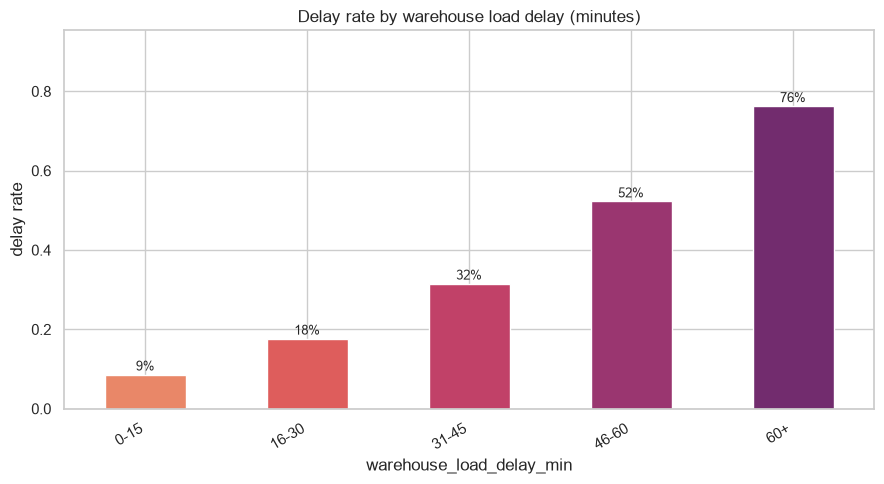

_grp
0-15     0.086064
16-30    0.176605
31-45    0.315380
46-60    0.522569
60+      0.762712
Name: is_delayed, dtype: float64

In [39]:
delay_rate_by('warehouse_load_delay_min',
              bins=[-1, 15, 30, 45, 60, 300],
              labels=['0-15', '16-30', '31-45', '46-60', '60+'],
              title='Delay rate by warehouse load delay (minutes)')

### 3b · Route start delay

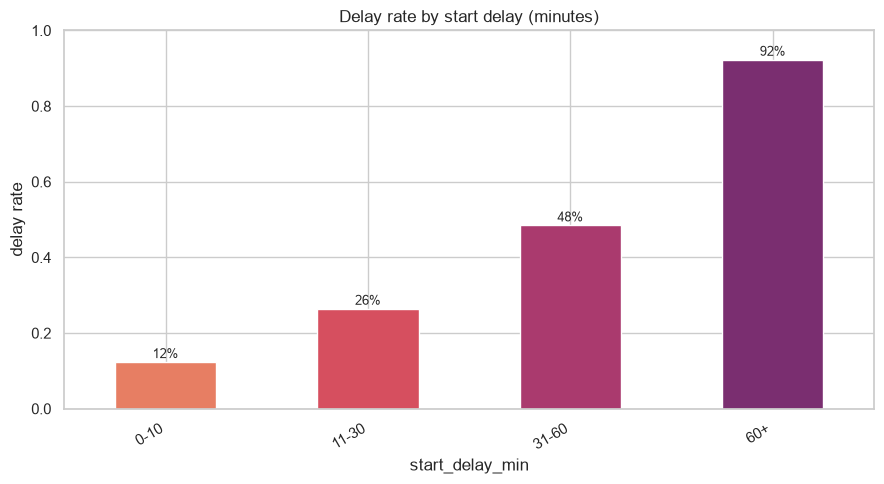

_grp
0-10     0.123760
11-30    0.264716
31-60    0.484985
60+      0.923077
Name: is_delayed, dtype: float64

In [40]:
delay_rate_by('start_delay_min',
              bins=[-1, 10, 30, 60, 200],
              labels=['0-10', '11-30', '31-60', '60+'],
              title='Delay rate by start delay (minutes)')

### 3c · Planned stop count (route complexity)

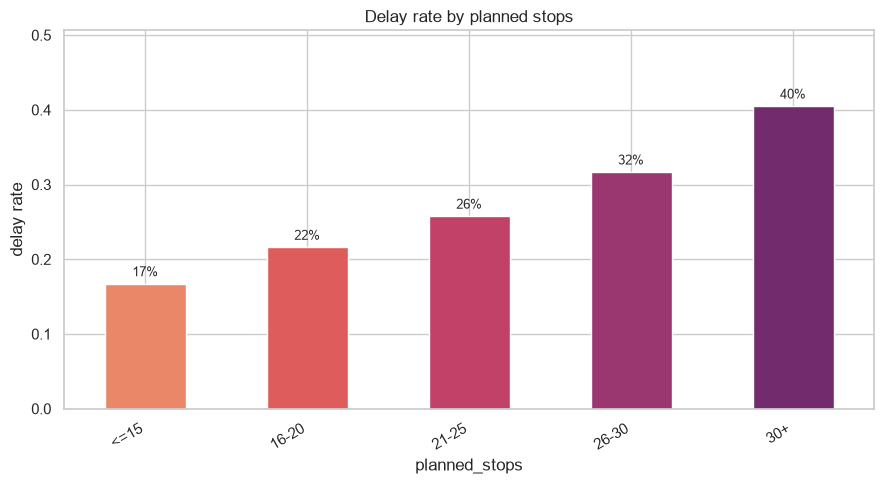

_grp
<=15     0.167210
16-20    0.216057
21-25    0.257655
26-30    0.316765
30+      0.404959
Name: is_delayed, dtype: float64

In [41]:
delay_rate_by('planned_stops',
              bins=[0, 15, 20, 25, 30, 50],
              labels=['<=15', '16-20', '21-25', '26-30', '30+'],
              title='Delay rate by planned stops')

### 3d · Traffic index

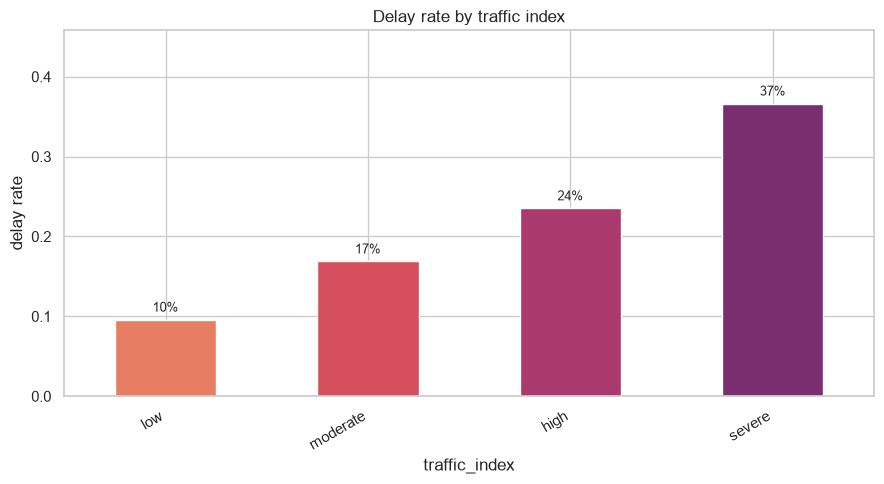

_grp
low         0.095758
moderate    0.168610
high        0.235180
severe      0.366246
Name: is_delayed, dtype: float64

In [42]:
delay_rate_by('traffic_index',
              bins=[0, 40, 55, 70, 100],
              labels=['low', 'moderate', 'high', 'severe'],
              title='Delay rate by traffic index')

### 3e · Driver familiarity, window pressure, route type, day of week, DC

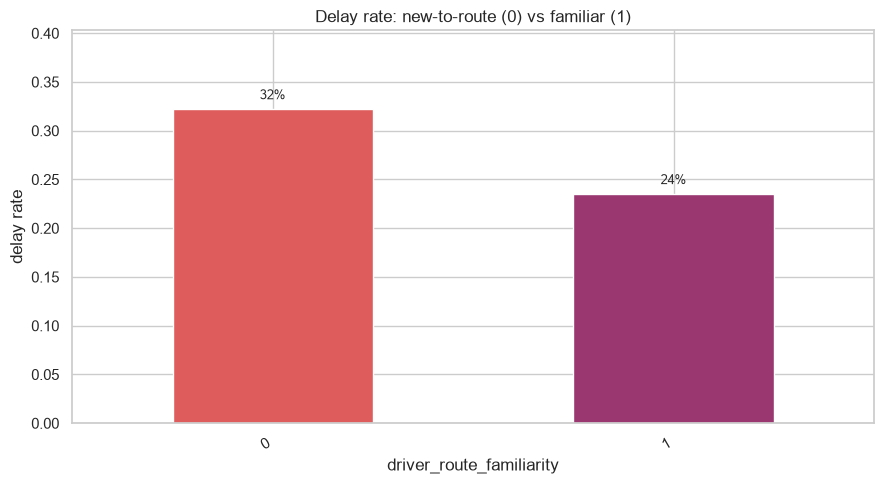

_grp
0    0.322240
1    0.235214
Name: is_delayed, dtype: float64

In [43]:
delay_rate_by('driver_route_familiarity',
              order=[0, 1],
              title='Delay rate: new-to-route (0) vs familiar (1)')

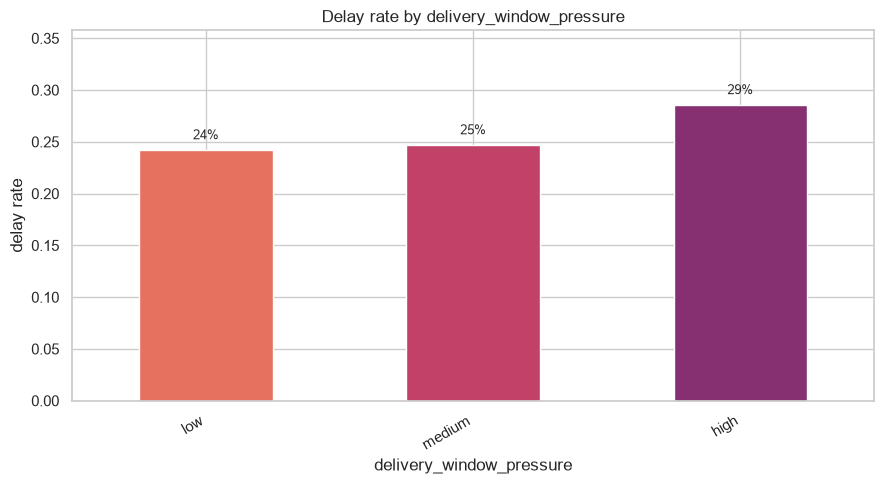

_grp
low       0.242456
medium    0.247258
high      0.286013
Name: is_delayed, dtype: float64

In [44]:
delay_rate_by('delivery_window_pressure', order=['low', 'medium', 'high'])

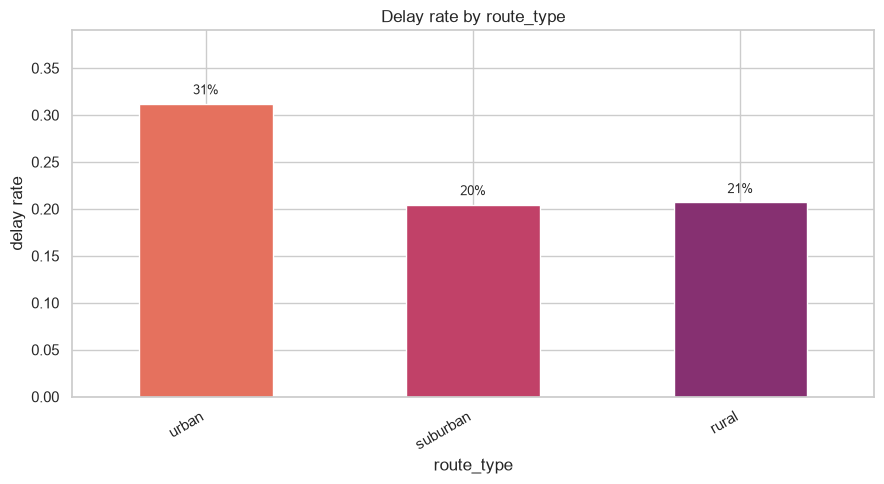

_grp
urban       0.312069
suburban    0.204652
rural       0.206882
Name: is_delayed, dtype: float64

In [45]:
delay_rate_by('route_type', order=['urban', 'suburban', 'rural'])

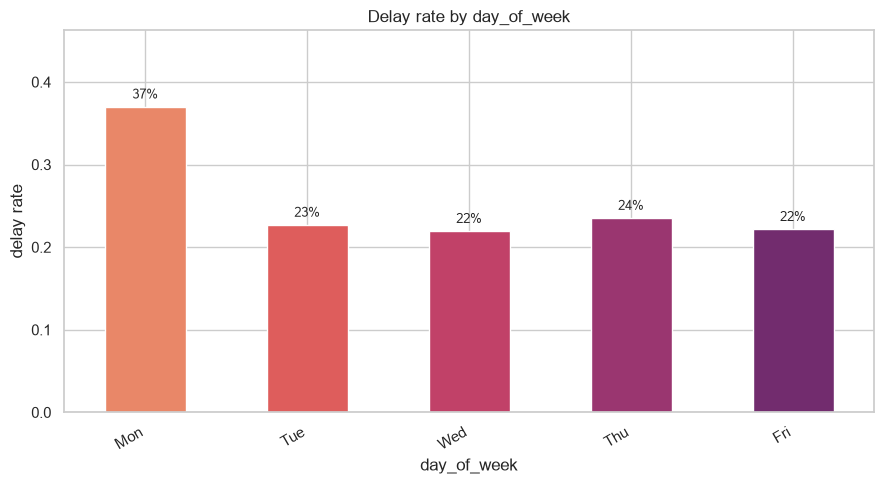

_grp
Mon    0.369899
Tue    0.226791
Wed    0.219298
Thu    0.235174
Fri    0.221669
Name: is_delayed, dtype: float64

In [46]:
delay_rate_by('day_of_week', order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])

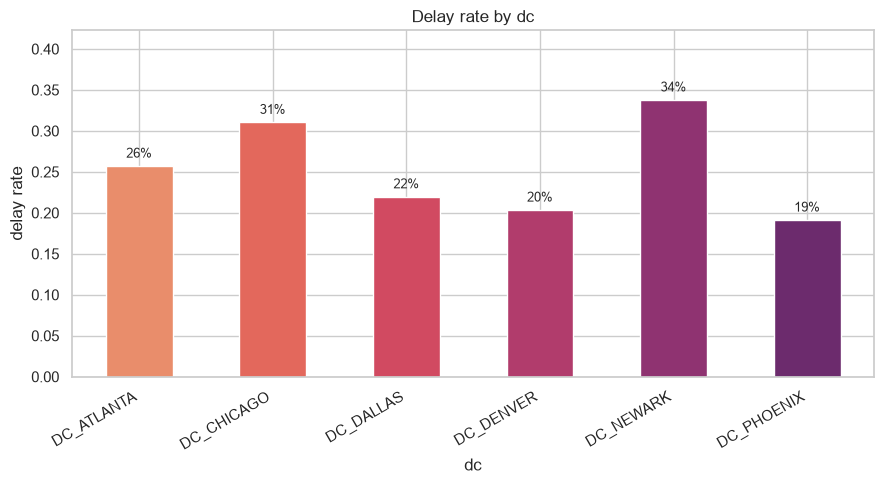

_grp
DC_NEWARK     0.338057
DC_CHICAGO    0.310694
DC_ATLANTA    0.257342
DC_DALLAS     0.219893
DC_DENVER     0.203694
DC_PHOENIX    0.191479
Name: is_delayed, dtype: float64

In [47]:
delay_rate_by('dc').sort_values(ascending=False)

## 4 · Do delayed vs on-time routes look different?

Overlaid distributions. Where the two curves separate, the feature carries signal the
model can use. Where they overlap heavily, it doesn't.


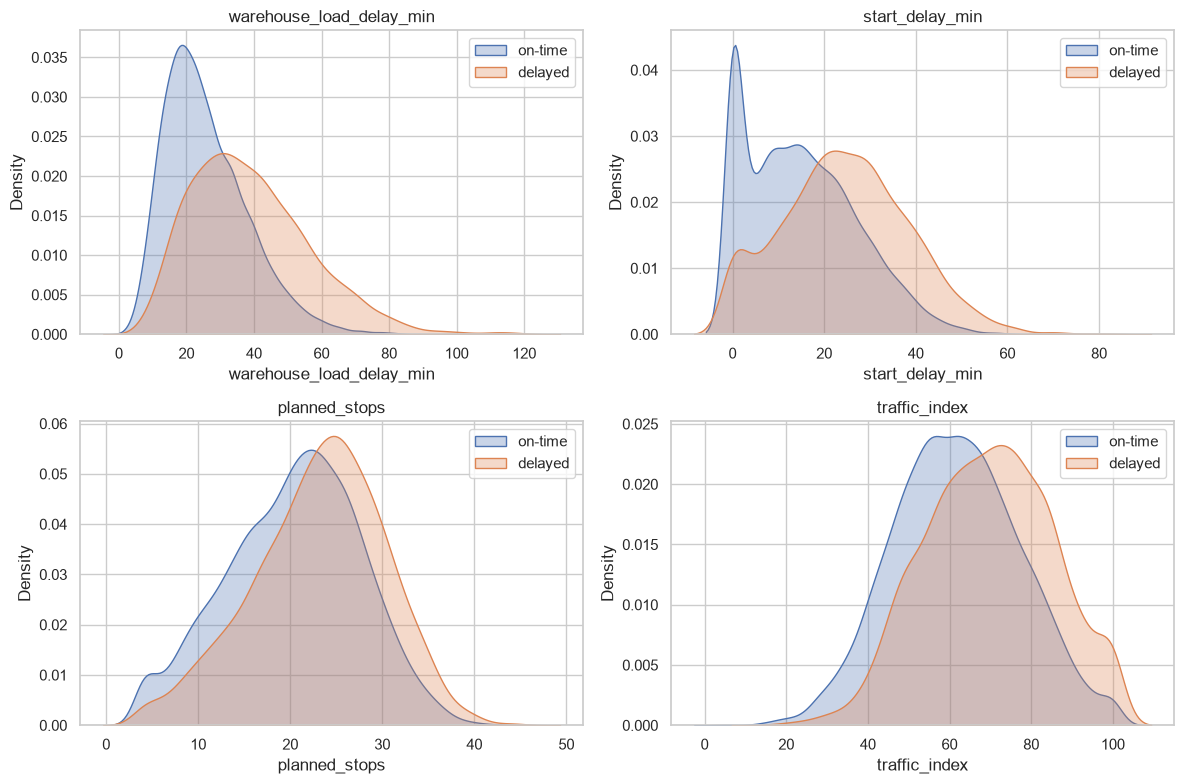

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat,
                   ['warehouse_load_delay_min', 'start_delay_min',
                    'planned_stops', 'traffic_index']):
    for lab, g in df.groupby('is_delayed'):
        sns.kdeplot(g[col], ax=ax, fill=True, alpha=0.3,
                    label='delayed' if lab == 1 else 'on-time')
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

## 5 · Correlation with the target — and the leakage guardrail

We correlate only the **allowed features** (`dg.FEATURE_COLUMNS`) with the target.
The `actual_*` and `route_delay_min` columns are deliberately excluded here: they are the
**outcome**, known only after the route ends. Including them would inflate everything and
produce a model that "cheats." This cell is where we prove we respect that boundary.


In [49]:
num_features = [c for c in dg.FEATURE_COLUMNS
                if pd.api.types.is_numeric_dtype(df[c])]

corr_with_target = (df[num_features]
                    .corrwith(df['is_delayed'])
                    .sort_values(ascending=False))
print("Correlation of each allowed feature with is_delayed:\n")
print(corr_with_target.round(3).to_string())

Correlation of each allowed feature with is_delayed:

warehouse_load_delay_min    0.379
start_delay_min             0.316
traffic_index               0.218
picker_shortage_flag        0.176
load_complexity_score       0.172
planned_stops               0.162
driver_avg_delay_rate       0.159
planned_duration_min        0.134
planned_cases               0.131
is_monday                   0.130
planned_weight_lbs          0.129
weather_severity            0.066
restaurant_stop_pct         0.008
holiday_week_flag           0.000
retail_stop_pct            -0.006
is_month_end               -0.008
driver_tenure_days         -0.029
planned_miles              -0.067
driver_route_familiarity   -0.081


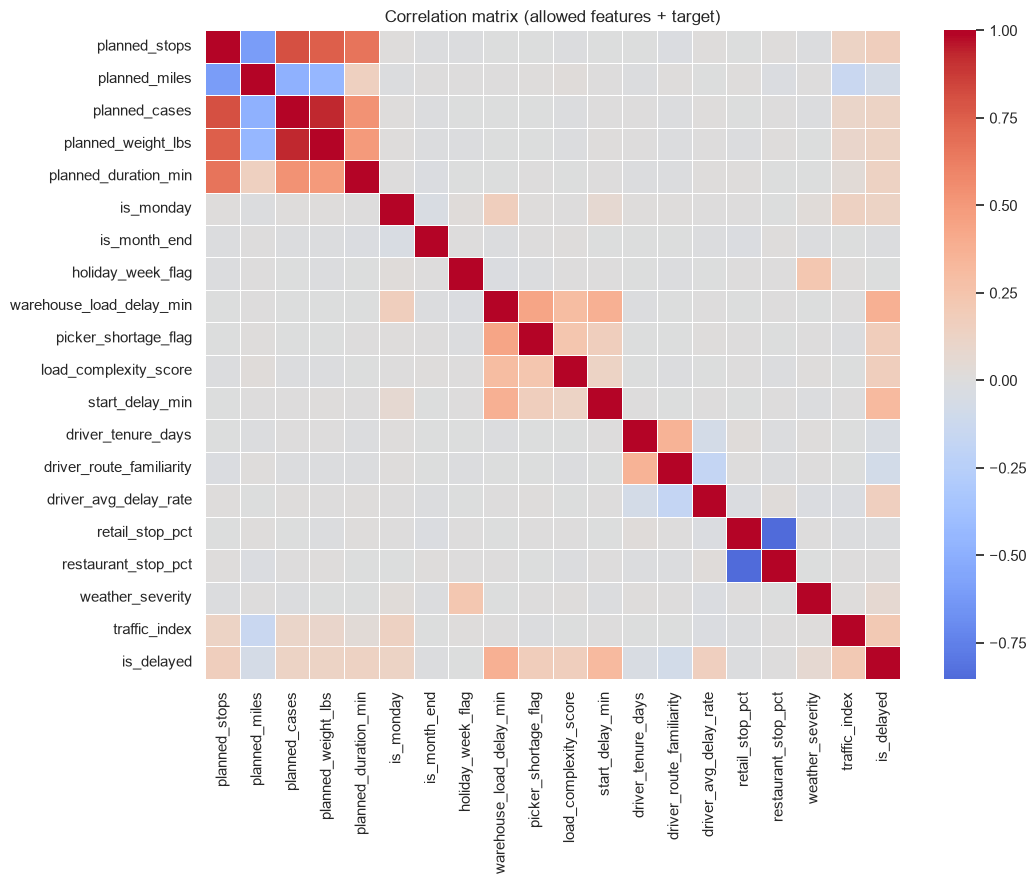

In [50]:
plt.figure(figsize=(11, 9))
sns.heatmap(df[num_features + ['is_delayed']].corr(),
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation matrix (allowed features + target)')
plt.tight_layout(); plt.show()

In [51]:
# The leakage contract, made explicit
print("SAFE features (usable at dispatch):")
print(dg.FEATURE_COLUMNS)
print("\nLEAKAGE columns (never features):", dg.LEAKAGE_COLUMNS)
print("TARGET:", dg.TARGET_COLUMN)
print("\nWhy route_delay_min is off-limits -- it IS the target:")
df[['route_delay_min', 'is_delayed']].head(8)

SAFE features (usable at dispatch):
['planned_stops', 'planned_miles', 'planned_cases', 'planned_weight_lbs', 'planned_duration_min', 'day_of_week', 'is_monday', 'is_month_end', 'holiday_week_flag', 'warehouse_load_delay_min', 'picker_shortage_flag', 'load_complexity_score', 'start_delay_min', 'driver_tenure_days', 'driver_route_familiarity', 'driver_avg_delay_rate', 'delivery_window_pressure', 'retail_stop_pct', 'restaurant_stop_pct', 'weather_severity', 'traffic_index', 'dc', 'region', 'route_type', 'vehicle_type']

LEAKAGE columns (never features): ['actual_duration_min', 'actual_end_offset_min', 'route_delay_min']
TARGET: is_delayed

Why route_delay_min is off-limits -- it IS the target:


,route_delay_min,is_delayed
0,-76,0
1,-45,0
2,-23,0
3,-59,0
4,-46,0
5,-15,0
6,18,0
7,35,1


## 6 · Key insights (the story so far)

Fill this in with the numbers you see above — this becomes the narrative for your
Root Cause dashboard page and your interview walkthrough. Starter template:

- **Warehouse load delay is the dominant lever.** Routes loaded 60+ min late are delayed
  at ~X%, versus ~Y% when loaded on time — a Zx difference.
- **Start delay compounds it.** (cause → effect: late loading → late departure → late finish)
- **Complexity matters.** More planned stops and higher traffic each raise the delay rate.
- **Driver route familiarity** shows a measurable gap between new-to-route and familiar drivers.
- **High delivery-window pressure** routes are more likely to miss.
- Delay rate varies by **DC**, pointing to site-level operational differences worth investigating.

**Next step (Step 3):** feature engineering — turn these raw signals into model-ready
inputs (`cases_per_stop`, `miles_per_stop`, `start_delay_bucket`, `is_new_driver`,
`high_complexity_route`), then train the baseline model.
